In [19]:
import warnings

warnings.filterwarnings("ignore")

import pyscenic
import loompy as lp
import scanpy as sc
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
import omicverse as ov
ov.plot_set()

2024-11-25 21:20:07.107553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-25 21:20:07.120997: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-25 21:20:07.125208: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-25 21:20:07.135460: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-25 21:20:07.823297: W tensorflow/compiler/tf2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [20]:
import omicverse as ov
ov.plot_set()

Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [21]:
adata=ov.read('data/GC_ST/GAS_GC_RAW_velo.h5ad')
adata=adata[adata.obs['CancerStage'].isin(['No','T1'])]
adata

View of AnnData object with n_obs × n_vars = 22357 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    

In [22]:
adata.var.index.name='gene'
adata.obs.index.name='cell'

In [5]:
adata.X.max(),adata.layers['matrix'].max()

(24749.0, 23804.0)

In [23]:
%%time
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata

Begin robust gene identification
After filtration, 32556/38606 genes are kept.     Among 32556 genes, 24227 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV6-21', 'IGKV2-24', 'IGKV1-27', 'IGKV2-28', 'IGKV2-29', 'IGKV2-30', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-28', 'IGKV2D-24', 'IGKV6D-21', 'IGKV3D-20', 'IGKV3D-15', 'SST', 'JCHAIN', 'MLN', 'PGC', 'DEFA6', 'DEFA5', 'LIPF', 'HBB', 'PGA3', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'IGHV6-1', 'IGHV1-2', 'IGHV7-4-1', 'IGHV2-5', 'IGHV3-7', 'IGHV1-18', 'IGHV3-21', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV4-34', 'IGHV4-39', 'IGHV1-46', 'IGHV3-48', 'IGHV3-49', 'IGHV5-51', 'IGHV1-58', 'IGHV4-59', 'IGHV1

AnnData object with n_obs × n_vars = 22357 × 24227
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'best_celltype_colors', 'log1p'

In [40]:
tfs_path = "allTFs_hg38.txt"
loom_path = "data/GC_RNA/gc_gas_processed_input.loom"
loom_path_output = "data/GC_RNA/gc_gas_processed_output.loom"
tfs = [tf.strip() for tf in open(tfs_path)]

In [9]:
import numpy as np
# as a general QC. We inspect that our object has transcription factors listed in our main annotations.
print(
    f"%{np.sum(adata.var.index.isin(tfs))} out of {len(tfs)} TFs are found in the object"
)

%1537 out of 1797 TFs are found in the object


In [12]:
use_hvg = True
if use_hvg:
    mask = (adata.var["highly_variable_features"] == True) | adata.var.index.isin(
        tfs
    )
    adata = adata[:, mask]

In [13]:
adata

View of AnnData object with n_obs × n_vars = 22357 × 4379
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'best_celltype_colors', 

In [14]:
row_attributes = {
    "Gene": np.array(adata.var.index),
}
col_attributes = {
    "CellID": np.array(adata.obs.index),
    "nGene": np.array(np.sum(adata.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata.X.transpose(), axis=0)).flatten(),
}

lp.create(loom_path, adata.X.transpose(), row_attributes, col_attributes)

In [15]:
num_workers = 8
outpath_adj = "result/scenic/adj.csv"
if not os.path.exists(outpath_adj):
    !pyscenic grn {loom_path} {tfs_path} -o $outpath_adj --num_workers {num_workers}

/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/mnt/home/zehuaz

In [22]:
results_adjacencies = pd.read_csv("result/scenic/adj.csv", index_col=False, sep=",")
print(f"Number of associations: {results_adjacencies.shape[0]}")
results_adjacencies.head()

Number of associations: 393613


,TF,target,importance
0,FOS,FOSB,39.045854
1,RBFOX2,APOO,37.287718
2,RBFOX2,PTPRCAP,33.523130
3,ELF3,CYSTM1,32.372531
4,ELF3,KRT8,31.420600


In [17]:
import glob
import os

# ranking databases
db_glob = "/mnt/home/zehuazeng/data/scenic/databases/*feather"
db_names = " ".join(glob.glob(db_glob))
# motif databases
motif_path = "/mnt/home/zehuazeng/data/scenic/motif/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl"

In [18]:
db_names='/mnt/home/zehuazeng/data/scenic/databases/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather'

In [19]:
%%time
outpath_reg='result/scenic/reg.csv'
if not os.path.exists(outpath_reg):
    !pyscenic ctx result/scenic/adj.csv \
        {db_names} \
        --annotations_fname {motif_path} \
        --expression_mtx_fname {loom_path} \
        --output {outpath_reg} \
        --mask_dropouts \
        --num_workers {num_workers} > result/scenic/pyscenic_ctx_stdout.txt

/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/mnt/home/zehuaz

In [20]:
%%time
if not os.path.exists(loom_path_output):
    !pyscenic aucell $loom_path \
        {outpath_reg} \
        --output {loom_path_output} \
        --num_workers {num_workers} > result/scenic/pyscenic_aucell_stdout.txt

/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/mnt/home/zehuaz

In [23]:
import json
import zlib
import base64

# collect SCENIC AUCell output
lf = lp.connect(loom_path_output, mode="r+", validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [25]:
import anndata as ad

ad_auc_mtx = ad.AnnData(auc_mtx)
ad_auc_mtx.obs=adata.obs.loc[ad_auc_mtx.obs.index]
ad_auc_mtx.write('data/GC_RNA/gc_gas_aucmtx.h5ad',compression='gzip')

In [32]:
ad_auc_mtx=sc.read('data/GC_RNA/gc_gas_aucmtx.h5ad',compression='gzip')

In [33]:
ad_auc_mtx

AnnData object with n_obs × n_vars = 22357 × 160
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'

In [34]:
ad_auc_mtx.X.max()

0.8831050228310502

In [35]:
ad_auc_mtx.layers['aucell']=ad_auc_mtx.X

In [36]:
%%time
ov.pp.pca(ad_auc_mtx,layer='aucell',n_pcs=50)
ad_auc_mtx

computing PCA
    with n_comps=50
    finished (0:00:00)
CPU times: user 4.65 s, sys: 2.17 s, total: 6.82 s
Wall time: 586 ms


AnnData object with n_obs × n_vars = 22357 × 160
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    uns: 'pca', 'aucell|original|pca_var_ratios', 'aucell|original|cum_sum_eigenvalues'
    obsm: 'X_pca', 'aucell|original|X_pca'
    varm: 'PCs', 'aucell|original|pca_loadings'
    layers: 'aucell'

In [37]:
ov.pp.mde(ad_auc_mtx,embedding_dim=2,n_neighbors=15, basis='X_mde',
          n_pcs=50, use_rep='aucell|original|X_pca',)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsm['X_mde']`, MDE coordinates
    `.obsp['neighbors_distances']`, distances for each pair of neighbors
    `.obsp['neighbors_connectivities']`, weighted adjacency matrix (0:00:18)


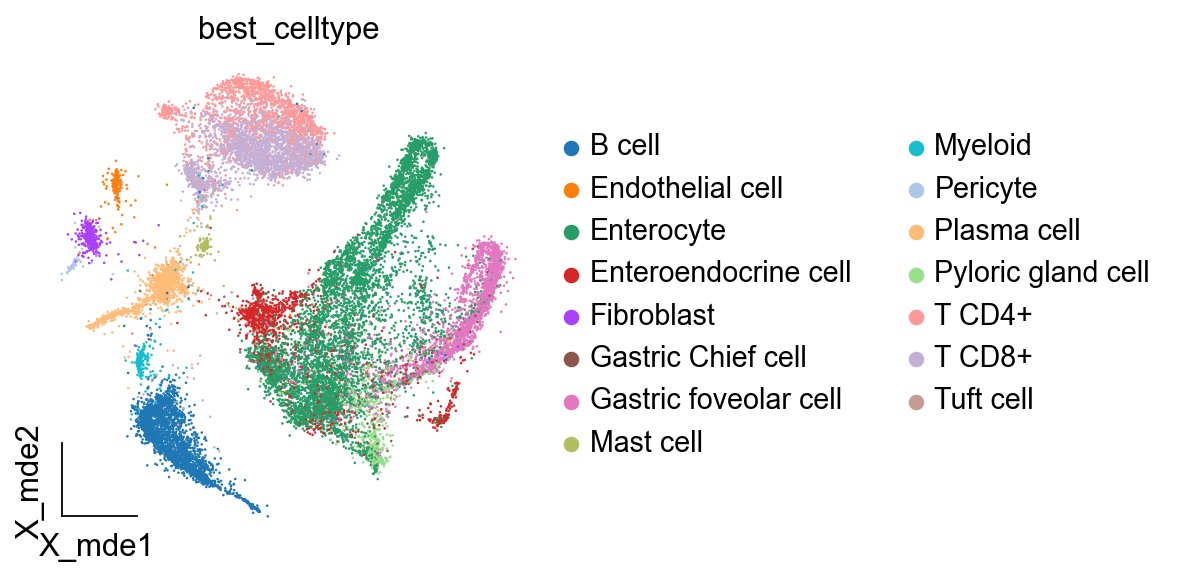

In [38]:
ov.pl.embedding(ad_auc_mtx,
                basis='X_mde',
                color='best_celltype',
                frameon='small')

In [41]:
import loompy as lp
import pandas as pd

lf = lp.connect(loom_path_output, mode='r', validate=False )

regulons = {}
for i,r in pd.DataFrame(lf.ra.Regulons,index=lf.ra.Gene).iteritems():
    regulons[i] =  list(r[r==1].index.values)

#regulon_of_interest = 'EBF1_(+)'
#regulons[regulon_of_interest]

Storing dendrogram info using `.uns['dendrogram_best_celltype']`
ranking genes
    finished: added to `.uns['best_celltype_ttest']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


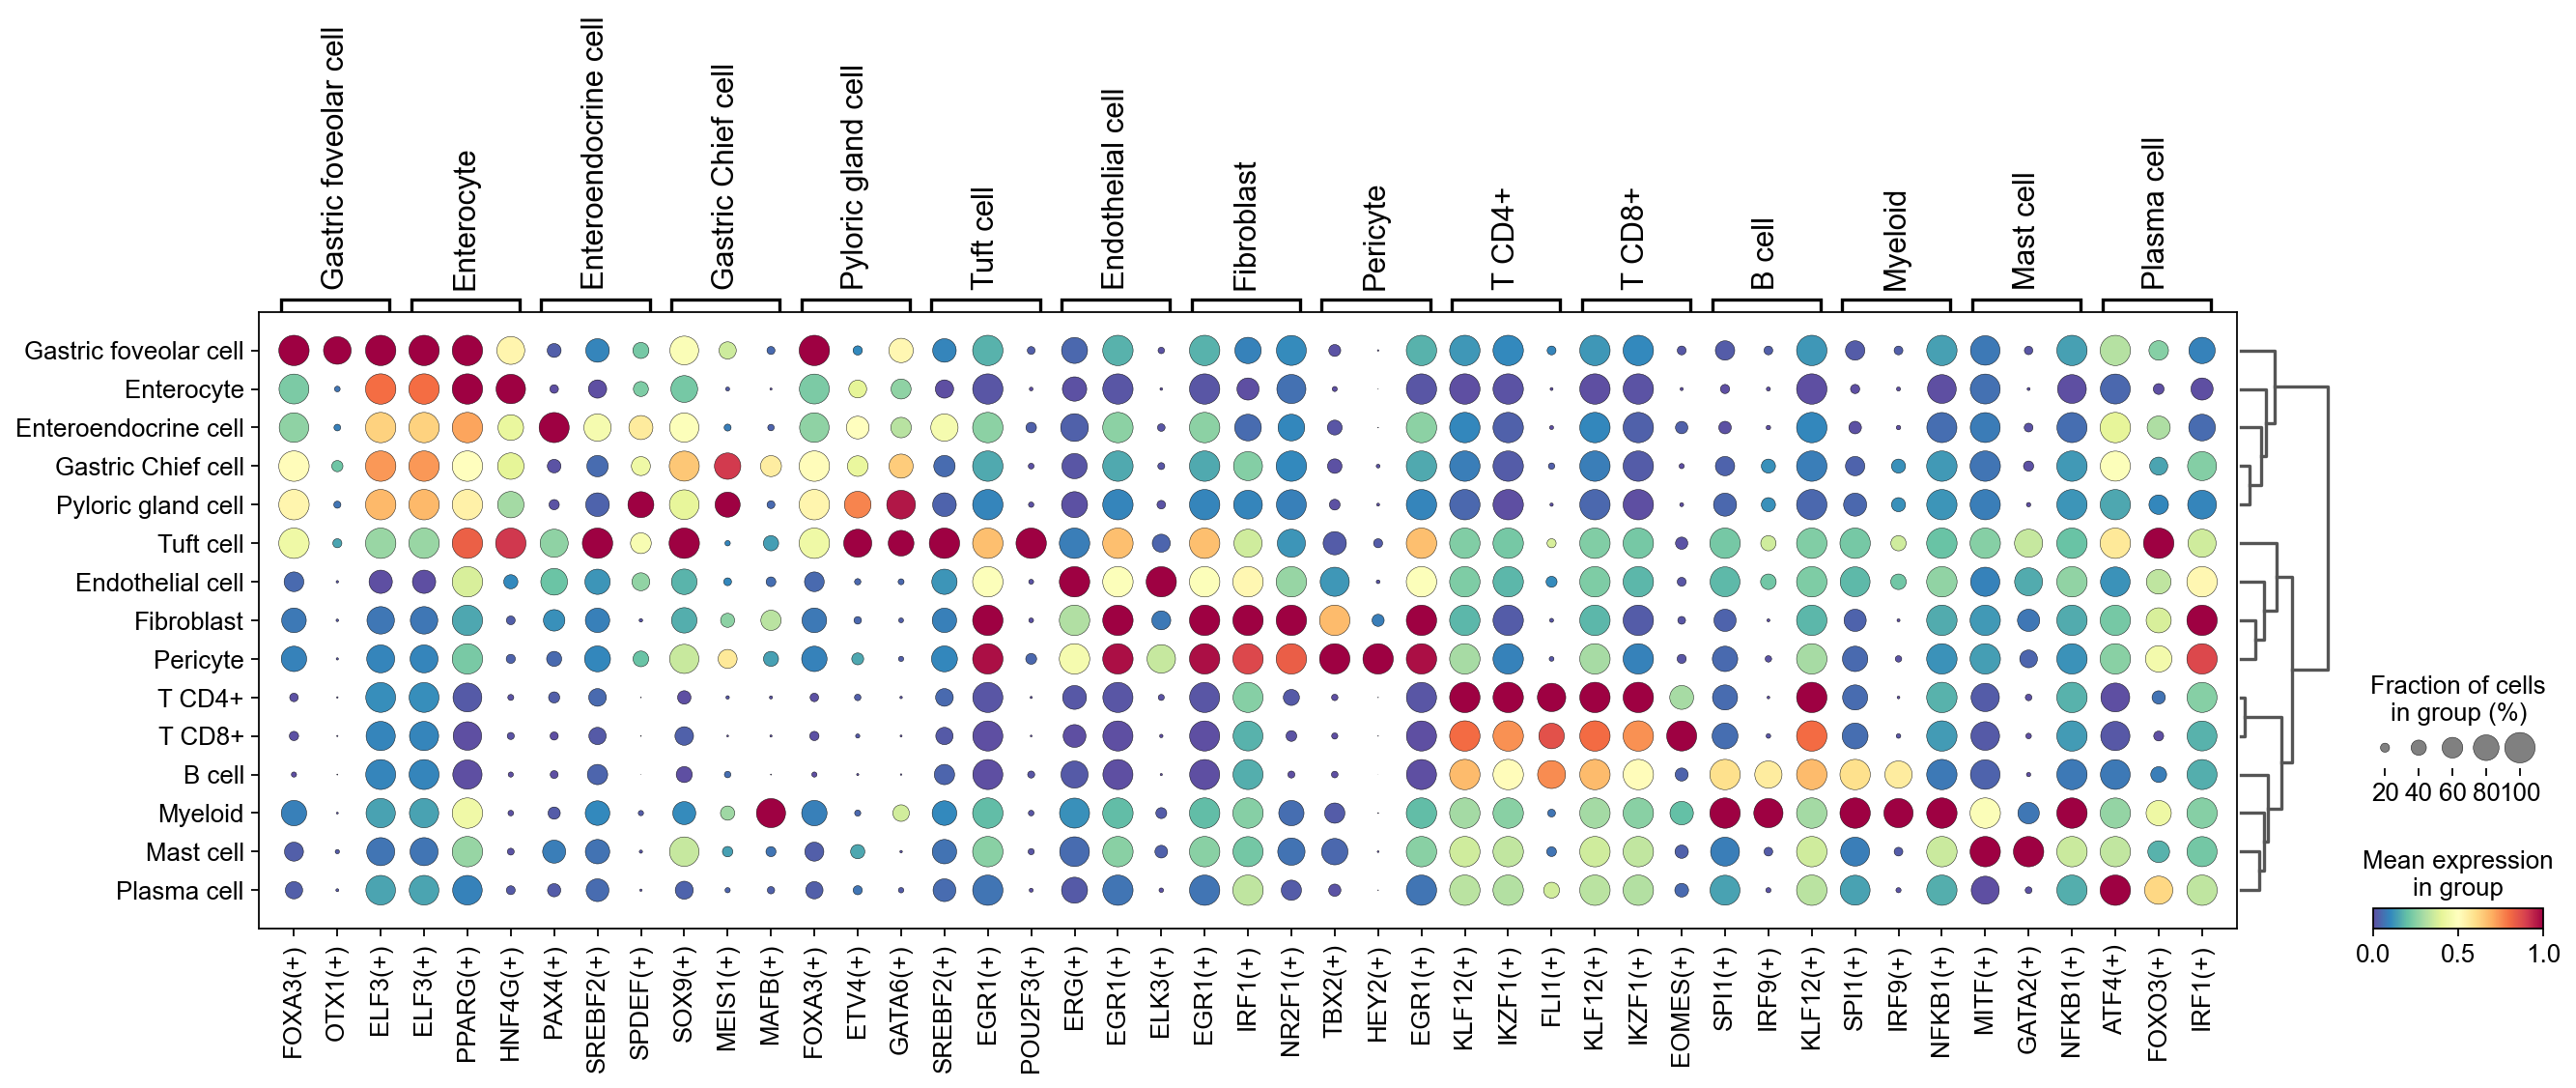

In [42]:
sc.tl.dendrogram(ad_auc_mtx,'best_celltype',use_rep='aucell|original|X_pca')
sc.tl.rank_genes_groups(ad_auc_mtx, 'best_celltype', use_rep='aucell|original|X_pca',
                        method='t-test',use_raw=False,key_added='best_celltype_ttest')
sc.pl.rank_genes_groups_dotplot(ad_auc_mtx,groupby='best_celltype',
                                cmap='Spectral_r',key='best_celltype_ttest',
                                standard_scale='var',n_genes=3)

In [44]:
degs = sc.get.rank_genes_groups_df(ad_auc_mtx, group='Plasma cell', key='best_celltype_ttest', log2fc_min=1, 
                                            pval_cutoff=0.05)
degs

,names,scores,logfoldchanges,pvals,pvals_adj
0,ATF4(+),110.611534,1.933597,0.000000e+00,0.000000e+00
1,FOXO3(+),39.935268,2.021712,1.041883e-249,9.805955e-249
2,BACH1(+),9.132315,1.528265,1.769379e-19,3.825685e-19
3,DMBX1(+),3.217627,1.255593,1.315691e-03,1.814746e-03


In [45]:
ct_markers=ov.single.get_celltype_marker(ad_auc_mtx,rank=True,clustertype='best_celltype',foldchange=1,
                             key='best_celltype_ttest',log2fc_min=1,scores_type='logfoldchanges'  )

...get cell type marker


In [46]:
import pandas as pd
active_tf_pd=pd.DataFrame()
all_marker=[]
all_ct=[]
for key in ct_markers:
    marker=[i.replace('(+)','') for i in ct_markers[key]]
    all_marker+=marker
    ct=[key for i in marker]
    all_ct+=ct
active_tf_pd['cluster']=all_ct
active_tf_pd['TF']=all_marker

In [47]:
active_tf_pd.to_csv('result/cpdb/active_tf.txt',sep='\t',index=None)

## DEGs

In [57]:
adata.X.max()

15.94376

In [48]:
for idx,ct in enumerate(list(set(adata.obs['best_celltype']))):
    test_adata=adata[adata.obs['best_celltype'].isin([ct])]
    test_adata.layers['lognorm']=test_adata.X
    dds=ov.bulk.pyDEG(test_adata.to_df(layer='lognorm').T)
    dds.drop_duplicates_index()
    #print('... drop_duplicates_index success')
    treatment_groups=test_adata.obs[test_adata.obs['CancerStage']=='T1'].index.tolist()
    control_groups=test_adata.obs[test_adata.obs['CancerStage']=='No'].index.tolist()
    result=dds.deg_analysis(treatment_groups,control_groups,method='ttest')
    # -1 means automatically calculates
    dds.foldchange_set(fc_threshold=1.5,
                       pval_threshold=0.05,
                       logp_max=10)
    
    if idx==0:
        result_up=dds.result.loc[dds.result['sig']=='up']
        result_down=dds.result.loc[dds.result['sig']=='down']
        result_down['clusters']=ct
        result_up['clusters']=ct
    else:
        result_up1=dds.result.loc[dds.result['sig']=='up']
        result_down1=dds.result.loc[dds.result['sig']=='down']
        result_down1['clusters']=ct
        result_up1['clusters']=ct
        result_up=pd.concat([result_up,result_up1],axis=0)
        result_down=pd.concat([result_down,result_down1],axis=0)

... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5
... Fold change threshold: 1.5


In [49]:
result_up['gene']=result_up.index.tolist()
result_up['cluster']=result_up['clusters'].tolist()
result_up['logFC']=result_up['log2FC'].tolist()
result_up['P.Value']=result_up['pvalue'].tolist()
result_up['adj.P.Val']=result_up['qvalue'].tolist()

In [50]:
result_down['gene']=result_down.index.tolist()
result_down['cluster']=result_down['clusters'].tolist()
result_down['logFC']=result_down['log2FC'].tolist()
result_down['P.Value']=result_down['pvalue'].tolist()
result_down['adj.P.Val']=result_down['qvalue'].tolist()

In [51]:
result_down

,pvalue,qvalue,FoldChange,MaxBaseMean,BaseMean,log2(BaseMean),log2FC,abs(log2FC),size,-log(pvalue),-log(qvalue),sig,clusters,gene,cluster,logFC,P.Value,adj.P.Val
gene,,,,,,,,,,,,,,,,,,
IGKC,0.000000,0.000000,0.040395,4.612135,2.399109,1.262499,-4.629689,4.629689,0.004039,inf,10.000000,down,Enterocyte,IGKC,Enterocyte,-4.629689,0.000000,0.000000
IGHA1,0.000000,0.000000,0.028813,3.798962,1.954097,0.966502,-5.117156,5.117156,0.002881,inf,10.000000,down,Enterocyte,IGHA1,Enterocyte,-5.117156,0.000000,0.000000
GSTA1,0.000000,0.000000,0.352514,3.366628,2.276630,1.186900,-1.504248,1.504248,0.035251,inf,10.000000,down,Enterocyte,GSTA1,Enterocyte,-1.504248,0.000000,0.000000
CLDN18,0.000000,0.000000,0.307525,3.352976,2.191970,1.132228,-1.701224,1.701224,0.030753,inf,10.000000,down,Enterocyte,CLDN18,Enterocyte,-1.701224,0.000000,0.000000
DMBT1,0.000000,0.000000,0.296443,2.812331,1.822932,0.866260,-1.754174,1.754174,0.029644,inf,10.000000,down,Enterocyte,DMBT1,Enterocyte,-1.754174,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WFDC3,0.006613,0.029065,0.016603,0.084106,0.042053,-4.571649,-5.912455,5.912455,0.001660,2.179621,1.536630,down,Enteroendocrine cell,WFDC3,Enteroendocrine cell,-5.912455,0.006613,0.029065
IL1R1,0.011882,0.048155,0.017288,0.080717,0.040358,-4.630991,-5.854117,5.854117,0.001729,1.925104,1.317361,down,Enteroendocrine cell,IL1R1,Enteroendocrine cell,-5.854117,0.011882,0.048155
FAIM2,0.007352,0.031820,0.017860,0.078086,0.039043,-4.678789,-5.807159,5.807159,0.001786,2.133571,1.497304,down,Enteroendocrine cell,FAIM2,Enteroendocrine cell,-5.807159,0.007352,0.031820


In [52]:
result_up[['cluster','gene','logFC','P.Value','adj.P.Val']].to_csv('data/cpdb/degs_gc.tsv',sep='\t',index=None)
result_down[['cluster','gene','logFC','P.Value','adj.P.Val']].to_csv('data/cpdb/degs_gas.tsv',sep='\t',index=None)

In [5]:
import pandas as pd
result_down=pd.read_csv('data/cpdb/degs_gas.tsv',sep='\t',index_col=0)
result_down

,gene,logFC,P.Value,adj.P.Val
cluster,,,,
B cell,SNHG5,-1.903609,0.000325,0.001517
B cell,S100A6,-1.839001,0.001196,0.005536
B cell,NPC2,-1.979657,0.000566,0.002634
B cell,S100A4,-2.002658,0.007756,0.035122
B cell,IGKC,-2.468205,0.000201,0.000939
...,...,...,...,...
Pyloric gland cell,PLXNA2,-8.459698,0.008919,0.040239
Pyloric gland cell,PDK4,-8.453482,0.011018,0.048827
Pyloric gland cell,DOCK9,-8.435892,0.010386,0.046239


In [ ]:
import numpy as np
result_down['logFC']=np.abs(result_down['logFC'])
result_down

In [11]:
result_down.to_csv('data/cpdb/degs_gas1.tsv',sep='\t')

## Cpdb
### gas

In [45]:
adata=ov.read('data/GC_ST/GAS_GC_RAW_velo.h5ad')
adata=adata[adata.obs['CancerStage'].isin(['No','T1'])]
adata

View of AnnData object with n_obs × n_vars = 22357 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    

In [46]:
adata.var.index.name='gene'
adata.obs.index.name='cell'

In [47]:
adata.X.max(),adata.layers['matrix'].max()

(24749.0, 23804.0)

In [48]:
%%time
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata

Begin robust gene identification
After filtration, 32556/38606 genes are kept.     Among 32556 genes, 24227 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV6-21', 'IGKV2-24', 'IGKV1-27', 'IGKV2-28', 'IGKV2-29', 'IGKV2-30', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-28', 'IGKV2D-24', 'IGKV6D-21', 'IGKV3D-20', 'IGKV3D-15', 'SST', 'JCHAIN', 'MLN', 'PGC', 'DEFA6', 'DEFA5', 'LIPF', 'HBB', 'PGA3', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'IGHV6-1', 'IGHV1-2', 'IGHV7-4-1', 'IGHV2-5', 'IGHV3-7', 'IGHV1-18', 'IGHV3-21', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV4-34', 'IGHV4-39', 'IGHV1-46', 'IGHV3-48', 'IGHV3-49', 'IGHV5-51', 'IGHV1-58', 'IGHV4-59', 'IGHV1

AnnData object with n_obs × n_vars = 22357 × 24227
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'best_celltype_colors', 'log1p'

In [49]:
adata

AnnData object with n_obs × n_vars = 22357 × 24227
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'best_celltype_colors', 'log1p'

In [50]:
import anndata
import pandas as pd
adata_oa_raw=adata[adata.obs['CancerStage']=='No']
adata_oa=anndata.AnnData(adata_oa_raw.X,obs=pd.DataFrame(index=adata_oa_raw.obs.index),
                          var=pd.DataFrame(index=adata_oa_raw.var.index))
adata_oa

AnnData object with n_obs × n_vars = 12676 × 24227

In [51]:
adata_oa.write('data/cpdb/gas_adata.h5ad',compression='gzip')

In [52]:
#meta导出
df_meta = pd.DataFrame(data={'Cell':list(adata_oa_raw[adata_oa.obs.index].obs.index),
                             'cell_type':[ i for i in adata_oa_raw[adata_oa.obs.index].obs['best_celltype']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv('data/cpdb/gas_meta.tsv', sep = '\t')

In [53]:
import os
cpdb_file_path = '/mnt/home/zehuazeng/data/cellphonedb/cellphonedb.zip'
meta_file_path = os.getcwd()+'/data/cpdb/gas_meta.tsv'
counts_file_path = os.getcwd()+'/data/cpdb/gas_adata.h5ad'
microenvs_file_path = None
degs_file_path = os.getcwd()+'/data/cpdb/degs_gas.tsv'
active_tf_path = os.getcwd()+'/result/cpdb/active_tf.txt'
out_path =os.getcwd()+'/result/cpdb/cpdb_gas'

In [54]:
from cellphonedb.src.core.methods import cpdb_degs_analysis_method

cpdb_results = cpdb_degs_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                            # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                            # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,                        # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    degs_file_path = degs_file_path,                            # mandatory: tsv file with DEG to account.
    counts_data = 'hgnc_symbol',                                # defines the gene annotation in counts matrix.
    active_tfs_file_path = active_tf_path,                      # optional: defines cell types and their active TFs.
    microenvs_file_path = microenvs_file_path,                  # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                                  # optional: whether to score interactions or not. 
    threshold = 0.1,                                            # defines the min % of cells expressing a gene for this to be employed in the analysis.
    result_precision = 3,                                       # Sets the rounding for the mean values in significan_means.
    separator = '|',                                            # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                              # Saves all intermediate tables emplyed during the analysis in pkl format.
    output_path = out_path,                                     # Path to save results
    output_suffix = None,                                       # Replaces the timestamp in the output files by a user defined string in the  (default: None)
    threads = 25
    )

[ ][CORE][25/11/24-21:24:30][INFO] [Cluster DEGs Analysis] Threshold:0.1 Precision:3
Reading user files...
Tuft cell
The following user files were loaded successfully:
/mnt/home/zehuazeng/analysis/24_GC/data/cpdb/gas_adata.h5ad
/mnt/home/zehuazeng/analysis/24_GC/data/cpdb/gas_meta.tsv
/mnt/home/zehuazeng/analysis/24_GC/result/cpdb/active_tf.txt
/mnt/home/zehuazeng/analysis/24_GC/data/cpdb/degs_gas.tsv
[ ][CORE][25/11/24-21:24:33][INFO] Running Real Analysis
[ ][CORE][25/11/24-21:24:33][INFO] Running DEGs-based Analysis
[ ][CORE][25/11/24-21:24:33][INFO] Building results
[ ][CORE][25/11/24-21:24:34][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 14/14 [00:00<00:00, 114.76it/s]

[ ][CORE][25/11/24-21:24:34][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 14/14 [00:00<00:00, 394.16it/s]


[ ][CORE][25/11/24-21:24:35][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 196/196 [00:45<00:00,  4.32it/s]


Saved deconvoluted to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_deconvoluted_11_25_2024_212521.txt
Saved deconvoluted_percents to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_deconvoluted_percents_11_25_2024_212521.txt
Saved means to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_means_11_25_2024_212521.txt
Saved relevant_interactions to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_relevant_interactions_11_25_2024_212521.txt
Saved significant_means to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_significant_means_11_25_2024_212521.txt
Saved CellSign_active_interactions to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_CellSign_active_interactions_11_25_2024_212521.txt
Saved CellSign_active_interactions_deconvoluted to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gas/degs_analysis_CellSign_active_interactions_deconvoluted_11_25_2024_

In [55]:
cpdb_results.keys()

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'relevant_interactions', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted', 'interaction_scores'])

In [56]:
cpdb_results['CellSign_active_interactions']

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,Pyloric gland cell|T CD4+,Pyloric gland cell|T CD8+,T CD4+|B cell,T CD4+|Myeloid,T CD4+|Plasma cell,T CD4+|Pyloric gland cell,T CD4+|T CD4+,T CD8+|B cell,T CD8+|Myeloid,T CD8+|Pyloric gland cell
0,CPI-CS0412B081A,DHEAsulfate_bySULT2B_PPARG,complex:DHEAsulfate_bySULT2B,simple:P37231,NaN,PPARG,True,False,True,curated,...,0,0,0,0,0,0,0,0,0,0
1,CPI-CS0917E42F5,DHEAsulfate_bySULT1E1_PPARG,complex:DHEAsulfate_bySULT1E1,simple:P37231,NaN,PPARG,True,False,True,curated,...,0,0,0,0,0,0,0,0,0,0


In [57]:
import omicverse as ov
ov.plot_set()
ov.utils.save(cpdb_results,'result/cpdb_results_gas.pkl')

Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


### healthy

In [53]:
import anndata
import pandas as pd
adata_h_raw=adata[adata.obs['CancerStage']=='T1']
adata_h=anndata.AnnData(adata_h_raw.X,obs=pd.DataFrame(index=adata_h_raw.obs.index),
                          var=pd.DataFrame(index=adata_h_raw.var.index))
adata_h

AnnData object with n_obs × n_vars = 9681 × 24227

In [54]:
adata_h.write('data/cpdb/gc_adata.h5ad',compression='gzip')

In [55]:
#meta导出
df_meta = pd.DataFrame(data={'Cell':list(adata_h_raw[adata_h.obs.index].obs.index),
                             'cell_type':[ i for i in adata_h_raw[adata_h.obs.index].obs['best_celltype']]
                            })
df_meta.set_index('Cell', inplace=True)
df_meta.to_csv('data/cpdb/gc_meta.tsv', sep = '\t')

In [58]:
import os
cpdb_file_path = '/mnt/home/zehuazeng/data/cellphonedb/cellphonedb.zip'
meta_file_path = os.getcwd()+'/data/cpdb/gc_meta.tsv'
counts_file_path = os.getcwd()+'/data/cpdb/gc_adata.h5ad'
microenvs_file_path = None
degs_file_path = os.getcwd()+'/data/cpdb/degs_gc.tsv'
active_tf_path = os.getcwd()+'/result/cpdb/active_tf.txt'
out_path =os.getcwd()+'/result/cpdb/cpdb_gc'

In [59]:
from cellphonedb.src.core.methods import cpdb_degs_analysis_method

cpdb_results_h = cpdb_degs_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                            # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                            # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,                        # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    degs_file_path = degs_file_path,                            # mandatory: tsv file with DEG to account.
    counts_data = 'hgnc_symbol',                                # defines the gene annotation in counts matrix.
    active_tfs_file_path = active_tf_path,                      # optional: defines cell types and their active TFs.
    microenvs_file_path = microenvs_file_path,                  # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                                  # optional: whether to score interactions or not. 
    threshold = 0.1,                                            # defines the min % of cells expressing a gene for this to be employed in the analysis.
    result_precision = 3,                                       # Sets the rounding for the mean values in significan_means.
    separator = '|',                                            # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                              # Saves all intermediate tables emplyed during the analysis in pkl format.
    output_path = out_path,                                     # Path to save results
    output_suffix = None,                                       # Replaces the timestamp in the output files by a user defined string in the  (default: None)
    threads = 25
    )

[ ][CORE][25/11/24-21:25:41][INFO] [Cluster DEGs Analysis] Threshold:0.1 Precision:3
Reading user files...
The following user files were loaded successfully:
/mnt/home/zehuazeng/analysis/24_GC/data/cpdb/gc_adata.h5ad
/mnt/home/zehuazeng/analysis/24_GC/data/cpdb/gc_meta.tsv
/mnt/home/zehuazeng/analysis/24_GC/result/cpdb/active_tf.txt
/mnt/home/zehuazeng/analysis/24_GC/data/cpdb/degs_gc.tsv
[ ][CORE][25/11/24-21:25:43][INFO] Running Real Analysis
[ ][CORE][25/11/24-21:25:43][INFO] Running DEGs-based Analysis
[ ][CORE][25/11/24-21:25:43][INFO] Building results
[ ][CORE][25/11/24-21:25:49][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 15/15 [00:00<00:00, 145.96it/s]

[ ][CORE][25/11/24-21:25:49][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 15/15 [00:00<00:00, 500.09it/s]


[ ][CORE][25/11/24-21:25:50][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 225/225 [00:56<00:00,  3.97it/s]


Saved deconvoluted to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_deconvoluted_11_25_2024_212648.txt
Saved deconvoluted_percents to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_deconvoluted_percents_11_25_2024_212648.txt
Saved means to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_means_11_25_2024_212648.txt
Saved relevant_interactions to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_relevant_interactions_11_25_2024_212648.txt
Saved significant_means to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_significant_means_11_25_2024_212648.txt
Saved CellSign_active_interactions to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_CellSign_active_interactions_11_25_2024_212648.txt
Saved CellSign_active_interactions_deconvoluted to /mnt/home/zehuazeng/analysis/24_GC/result/cpdb/cpdb_gc/degs_analysis_CellSign_active_interactions_deconvoluted_11_25_2024_212648.

In [60]:
ov.utils.save(cpdb_results_h,'result/cpdb_results_gc.pkl')